# Ensemble Methods

Voting, bagging, boosting and stacking compared against single models.

Dataset: Adult Income

Question: how much does combining models actually buy, and at what cost?

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

RANDOM_STATE = 42

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

RANDOM_STATE = 42

In [2]:
data = fetch_openml("adult", version=2, as_frame=True)

X = data.data
y = (data.target == ">50K").astype(int)

print("Full dataset:", X.shape)
print("Positive class:", y.mean())

Full dataset: (48842, 14)
Positive class: 0.23928176569346055


In [3]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Full training set:", X_train_full.shape)
print("Test set:", X_test.shape)

Full training set: (39073, 14)
Test set: (9769, 14)


In [4]:
X_train = X_train_full.sample(
    n=20_000,
    random_state=RANDOM_STATE
)

y_train = y_train_full.loc[X_train.index]

print("Training subset:", X_train.shape)
print("Test set:", X_test.shape)

Training subset: (20000, 14)
Test set: (9769, 14)


### Why use a 20,000-row training subset?

Ensemble methods can require many model fits. Bagging and Random Forest
train many trees, while stacking trains several base models and a
meta-model. To keep the experiments practical, the models are trained on
a 20,000-row subset of the training data.

The test set remains completely untouched until evaluation. Therefore the
test scores still provide an honest estimate of performance for these
trained models, although a model trained on the full training set might
perform somewhat differently.

In [5]:
num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), num_cols),

    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]), cat_cols)
])

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [24]:
results = []


def evaluate(name, classifier):
    """Fit, time, and evaluate a classifier on the test set."""

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", classifier)
    ])

    start = time.time()

    pipe.fit(X_train, y_train)

    fit_seconds = time.time() - start

    preds = pipe.predict(X_test)

    accuracy = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    try:
        probs = pipe.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, probs)
    except AttributeError:
        roc_auc = None

    result = {
        "model": name,
        "accuracy": accuracy,
        "f1": f1,
        "roc_auc": roc_auc,
        "fit_seconds": fit_seconds
    }

    results.append(result)

    print(f"{name}:")
    print(f"  Accuracy:    {accuracy:.4f}")
    print(f"  F1:          {f1:.4f}")
    print(f"  ROC-AUC:     {roc_auc if roc_auc is not None else 'N/A'}")
    print(f"  Fit time:    {fit_seconds:.2f}s")

    return pipe

In [7]:
singles = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "KNN (k=15)": KNeighborsClassifier(
        n_neighbors=15
    )
}

In [8]:
for name, model in singles.items():
    evaluate(name, model)

Logistic Regression:
  Accuracy:    0.8512
  F1:          0.6546
  ROC-AUC:     0.9039162576859086
  Fit time:    2.40s
Decision Tree:
  Accuracy:    0.8122
  F1:          0.6121
  ROC-AUC:     0.7460813996898067
  Fit time:    -0.40s
KNN (k=15):
  Accuracy:    0.8415
  F1:          0.6428
  ROC-AUC:     0.8862624540411075
  Fit time:    0.06s


In [9]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [10]:
evaluate("Bagging", bag)
evaluate("Random Forest", rf)

Bagging:
  Accuracy:    0.8570
  F1:          0.6756
  ROC-AUC:     0.9030650274512972
  Fit time:    7.98s
Random Forest:
  Accuracy:    0.8574
  F1:          0.6764
  ROC-AUC:     0.9028332400312704
  Fit time:    1.08s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['age','workclass','fnlwgt',...,'capital-loss','hours-per-week', 'native-country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [11]:
boosters = {
    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

In [12]:
for name, model in boosters.items():
    evaluate(name, model)

AdaBoost:
  Accuracy:    0.8582
  F1:          0.6652
  ROC-AUC:     0.9090868381467643
  Fit time:    2.73s
Gradient Boosting:
  Accuracy:    0.8687
  F1:          0.6875
  ROC-AUC:     0.9208261773931807
  Fit time:    4.67s
HistGradientBoosting:
  Accuracy:    0.8717
  F1:          0.7081
  ROC-AUC:     0.9257778347221586
  Fit time:    0.86s


In [13]:
voting_soft = VotingClassifier(
    estimators=[
        (
            "lr",
            LogisticRegression(max_iter=1000)
        ),
        (
            "rf",
            RandomForestClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        ),
        (
            "hgb",
            HistGradientBoostingClassifier(
                random_state=RANDOM_STATE
            )
        )
    ],
    voting="soft",
    n_jobs=-1
)

In [14]:
evaluate("Voting (soft)", voting_soft)

Voting (soft):
  Accuracy:    0.8679
  F1:          0.6955
  ROC-AUC:     0.9194498136779097
  Fit time:    4.23s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['age','workclass','fnlwgt',...,'capital-loss','hours-per-week', 'native-country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [15]:
voting_hard = VotingClassifier(
    estimators=[
        (
            "lr",
            LogisticRegression(max_iter=1000)
        ),
        (
            "rf",
            RandomForestClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        ),
        (
            "hgb",
            HistGradientBoostingClassifier(
                random_state=RANDOM_STATE
            )
        )
    ],
    voting="hard",
    n_jobs=-1
)

In [16]:
evaluate("Voting (hard)", voting_hard)

Voting (hard):
  Accuracy:    0.8690
  F1:          0.6980
  ROC-AUC:     N/A
  Fit time:    3.37s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['age','workclass','fnlwgt',...,'capital-loss','hours-per-week', 'native-country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [17]:
stack = StackingClassifier(
    estimators=[
        (
            "lr",
            LogisticRegression(max_iter=1000)
        ),
        (
            "rf",
            RandomForestClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        ),
        (
            "hgb",
            HistGradientBoostingClassifier(
                random_state=RANDOM_STATE
            )
        )
    ],

    final_estimator=LogisticRegression(),

    cv=3,
    n_jobs=-1
)

In [18]:
evaluate("Stacking", stack)

Stacking:
  Accuracy:    0.8728
  F1:          0.7087
  ROC-AUC:     0.9249340870712581
  Fit time:    10.07s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['age','workclass','fnlwgt',...,'capital-loss','hours-per-week', 'native-country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [19]:
results_df = pd.DataFrame(results).sort_values(
    "roc_auc",
    ascending=False,
    na_position="last"
)

results_df

,model,accuracy,f1,roc_auc,fit_seconds
7,HistGradientBoosting,0.871737,0.708130,0.925778,0.860188
10,Stacking,0.872761,0.708695,0.924934,10.069515
6,Gradient Boosting,0.868666,0.687454,0.920826,4.668987
8,Voting (soft),0.867950,0.695467,0.919450,4.227084
5,AdaBoost,0.858225,0.665216,0.909087,2.729310
0,Logistic Regression,0.851162,0.654632,0.903916,2.397721
3,Bagging,0.856997,0.675644,0.903065,7.983479
4,Random Forest,0.857406,0.676423,0.902833,1.082143
2,KNN (k=15),0.841540,0.642824,0.886262,0.060094
1,Decision Tree,0.812161,0.612133,0.746081,-0.395700


In [20]:
results_df.to_csv(
    "../reports/ensemble_comparison.csv",
    index=False
)

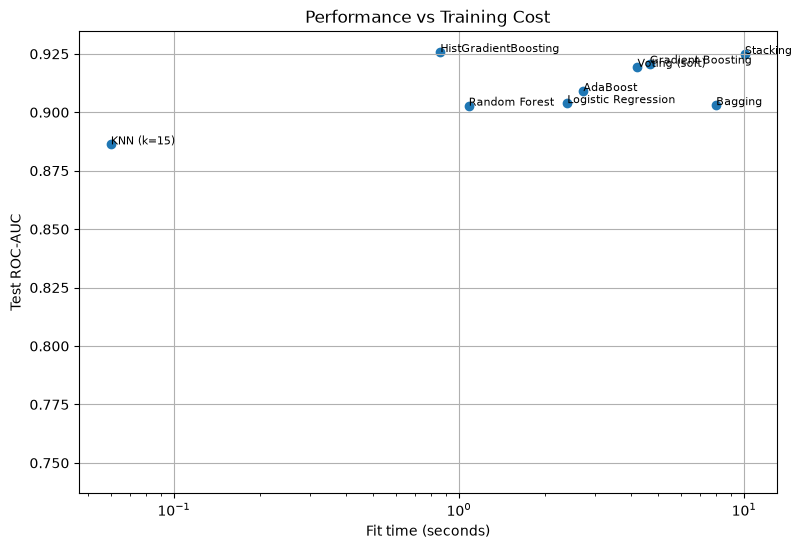

In [21]:
plot_df = results_df.dropna(subset=["roc_auc"])

plt.figure(figsize=(9, 6))

plt.scatter(
    plot_df["fit_seconds"],
    plot_df["roc_auc"]
)

for _, r in plot_df.iterrows():
    plt.annotate(
        r["model"],
        (r["fit_seconds"], r["roc_auc"]),
        fontsize=8
    )

plt.xlabel("Fit time (seconds)")
plt.ylabel("Test ROC-AUC")
plt.xscale("log")
plt.title("Performance vs Training Cost")
plt.grid(True)

plt.savefig(
    "../reports/ensemble_cost_benefit.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

In [22]:
results_df[[
    "model",
    "roc_auc",
    "f1",
    "fit_seconds"
]].sort_values(
    "roc_auc",
    ascending=False,
    na_position="last"
)

,model,roc_auc,f1,fit_seconds
7,HistGradientBoosting,0.925778,0.708130,0.860188
10,Stacking,0.924934,0.708695,10.069515
6,Gradient Boosting,0.920826,0.687454,4.668987
8,Voting (soft),0.919450,0.695467,4.227084
5,AdaBoost,0.909087,0.665216,2.729310
0,Logistic Regression,0.903916,0.654632,2.397721
3,Bagging,0.903065,0.675644,7.983479
4,Random Forest,0.902833,0.676423,1.082143
2,KNN (k=15),0.886262,0.642824,0.060094
1,Decision Tree,0.746081,0.612133,-0.395700


In [23]:
valid_results = results_df.dropna(subset=["roc_auc"])

best_overall = valid_results.iloc[0]

single_names = [
    "Logistic Regression",
    "Decision Tree",
    "KNN (k=15)"
]

best_single = (
    valid_results[
        valid_results["model"].isin(single_names)
    ]
    .sort_values("roc_auc", ascending=False)
    .iloc[0]
)

print("Best overall:")
print(best_overall)

print("\nBest single model:")
print(best_single)

print(
    f"\nROC-AUC improvement: "
    f"{best_overall['roc_auc'] - best_single['roc_auc']:.4f}"
)

Best overall:
model          HistGradientBoosting
accuracy                   0.871737
f1                          0.70813
roc_auc                    0.925778
fit_seconds                0.860188
Name: 7, dtype: object

Best single model:
model          Logistic Regression
accuracy                  0.851162
f1                        0.654632
roc_auc                   0.903916
fit_seconds               2.397721
Name: 0, dtype: object

ROC-AUC improvement: 0.0219


## Conclusion

HistGradientBoosting was the best overall model in this experiment,
achieving a test ROC-AUC of 0.9258, F1 of 0.7081, and accuracy of 0.8717.
It improved ROC-AUC by 0.0219 over the best single model, Logistic
Regression, which achieved 0.9039 ROC-AUC.

Boosting clearly outperformed bagging on this dataset. Bagging achieved
0.9031 ROC-AUC and Random Forest achieved 0.9028, while AdaBoost,
Gradient Boosting, and HistGradientBoosting achieved 0.9091, 0.9208,
and 0.9258 respectively. HistGradientBoosting was especially attractive
because it achieved the best ROC-AUC while fitting in only about 0.86
seconds.

Bagging and Random Forest were disappointing here. Both trained 100 trees
and landed at roughly 0.903 ROC-AUC — essentially the same as a single
Logistic Regression at 0.9039, which fits in a fraction of the time.

Bagging works by reducing variance, so it helps most when the base model
is unstable. Averaging 100 trees removed the single tree's overfitting,
but it could not find structure that the trees were not capturing in the
first place. Boosting improved on this because each model is trained
specifically on what the previous ones got wrong, which reduces bias
rather than variance.

Stacking achieved a very similar ROC-AUC of 0.9249 and the highest F1
of 0.7087, but took about 10.07 seconds to fit. This is roughly 12 times
slower than HistGradientBoosting while producing slightly worse ROC-AUC,
so stacking does not appear to justify its additional cost here.

The most important lesson is that combining models does not automatically
make a better model. The type of ensemble matters. Bagging and Random
Forest provided little improvement over Logistic Regression in this
experiment, while boosting produced a substantial improvement.

If I had to deploy one model from this experiment, I would choose
HistGradientBoosting. It provided the best ROC-AUC and F1 among the
models with ROC-AUC, while also having a very low training cost. The
small F1 advantage of stacking is not large enough to justify its much
higher training cost.

This conclusion is specific to this dataset and experiment. A different
dataset, metric, or cost of errors could make a different model the
better deployment choice.